# Netflix Dataset Analysis- By Sitesh Gupta
Content Trends Analysis for Strategic Recommendations

**1.Importing the Libraries**

In [221]:
import pandas as pd
import numpy as np

2.**Loading the Dataset**

In [222]:
df=pd.read_csv("Netflix Dataset.csv")

In [223]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [224]:
df.tail()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [225]:
print(df.columns)
df.shape

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')


(7789, 11)

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [227]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [228]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

**3. Data Cleaning**

In [229]:
# Handling the Missing Values
cols_to_fill_na = ['Director', 'Cast', 'Country']
df[cols_to_fill_na] = df[cols_to_fill_na].fillna('Unknown')
df['Rating']=df['Rating'].fillna('Not Rated')

In [231]:
# Drop rows with missing Release_Date as it's critical for time series analysis
df.dropna(subset=['Release_Date'], inplace=True)

In [232]:
# Convert 'Release_Date' to datetime
df['Release_Date'] = df['Release_Date'].str.strip()
df['Release_Date'] = pd.to_datetime(df['Release_Date'],errors='coerce')

In [ ]:
# Extract Year and Month for time-based analysis
df['Release_Year'] = df['Release_Date'].dt.year
df['Release_Month'] = df['Release_Date'].dt.month
# Extract Main Genre (first genre listed in 'Type')
df['Main_Genre'] = df['Type'].apply(lambda x: x.split(",")[0].strip() if pd.notnull(x) else "Unknown")

In [ ]:
print(df.columns)
df.shape

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description',
       'Release_Year', 'Release_Month', 'Main_Genre'],
      dtype='object')


(7779, 14)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7779 entries, 0 to 7788
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Show_Id        7779 non-null   object        
 1   Category       7779 non-null   object        
 2   Title          7779 non-null   object        
 3   Director       7779 non-null   object        
 4   Cast           7779 non-null   object        
 5   Country        7779 non-null   object        
 6   Release_Date   7779 non-null   datetime64[ns]
 7   Rating         7779 non-null   object        
 8   Duration       7779 non-null   object        
 9   Type           7779 non-null   object        
 10  Description    7779 non-null   object        
 11  Release_Year   7779 non-null   int32         
 12  Release_Month  7779 non-null   int32         
 13  Main_Genre     7779 non-null   object        
dtypes: datetime64[ns](1), int32(2), object(11)
memory usage: 850.8+ KB
None


In [ ]:
df.isnull().sum()

Show_Id          0
Category         0
Title            0
Director         0
Cast             0
Country          0
Release_Date     0
Rating           0
Duration         0
Type             0
Description      0
Release_Year     0
Release_Month    0
Main_Genre       0
dtype: int64

In [ ]:
df.describe()

,Release_Date,Release_Year,Release_Month
count,7779,7779.000000,7779.000000
mean,2019-01-02 21:30:59.005013504,2018.493637,6.783777
min,2008-01-01 00:00:00,2008.000000,1.000000
25%,2018-02-01 00:00:00,2018.000000,4.000000
50%,2019-03-08 00:00:00,2019.000000,7.000000
75%,2020-01-20 00:00:00,2020.000000,10.000000
max,2021-01-16 00:00:00,2021.000000,12.000000
std,NaN,1.388082,3.591373


**4.Data Visualizations**

In [ ]:
#Importing the Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

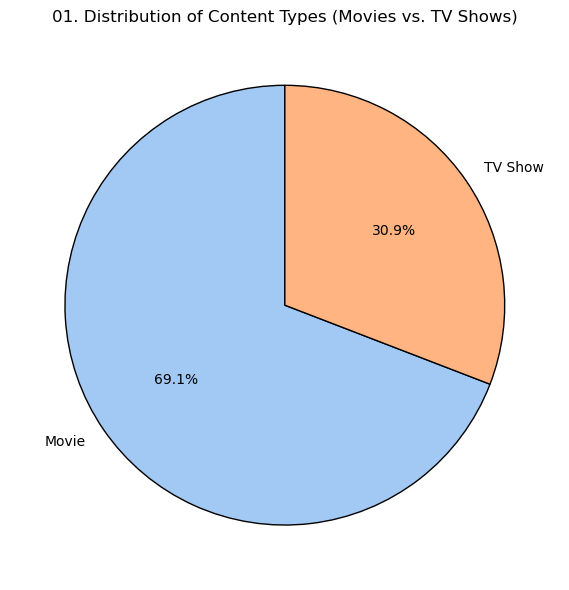

In [ ]:
# What: Shows the total proportion of Movies vs. TV Shows in the catalog.
content_counts = df['Category'].value_counts()
plt.figure(figsize=(12, 6))
plt.pie(
    content_counts.values,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title('01. Distribution of Content Types (Movies vs. TV Shows)')
plt.tight_layout()

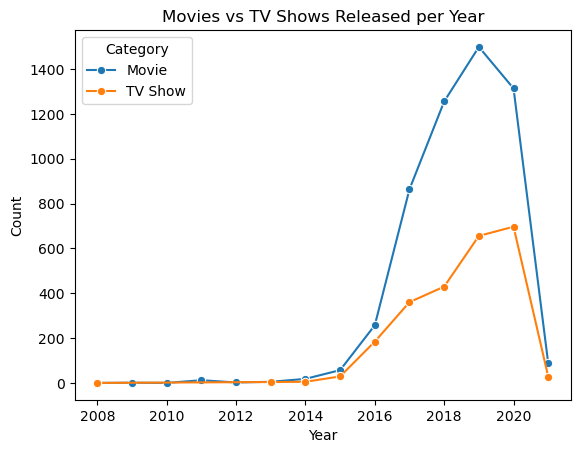

In [ ]:
# 1. Line Chart – Movies vs. TV Shows released per year
content_trend = df.groupby(['Release_Year', 'Category']).size().reset_index(name='Count')
sns.lineplot(data=content_trend, x='Release_Year', y='Count', hue='Category', marker='o')
plt.title("Movies vs TV Shows Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\2941333989.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




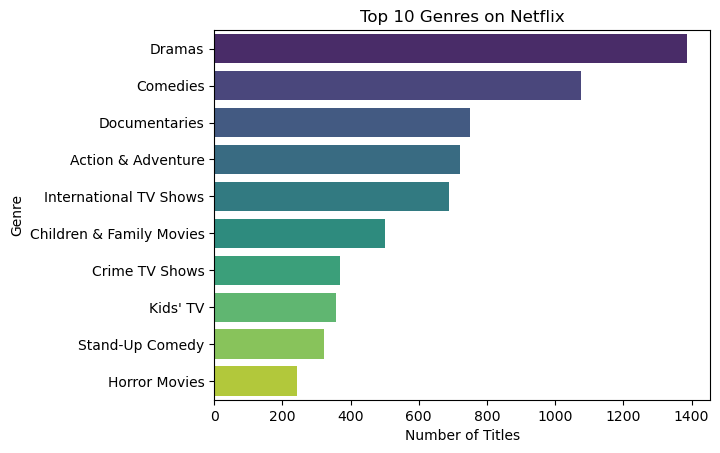

In [ ]:
# 2. Bar Chart – Top 10 Genres
top_genres = df['Main_Genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

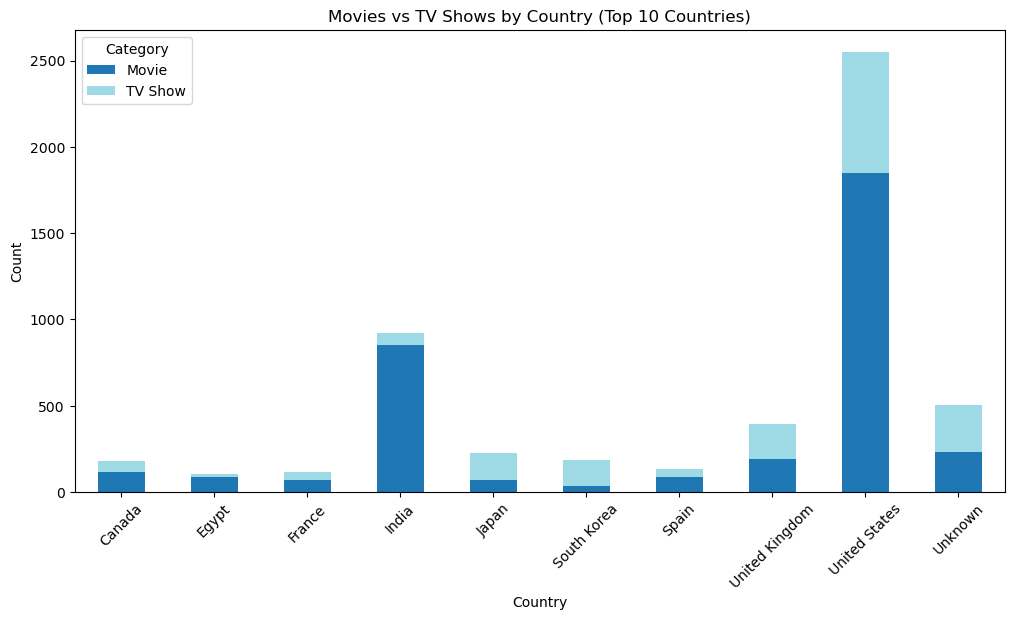

In [ ]:
# 3. Stacked Bar Chart – Movies vs TV Shows per Country (Top 10 countries)
top_countries = df['Country'].value_counts().head(10).index
country_data = df[df['Country'].isin(top_countries)]
stacked = country_data.groupby(['Country', 'Category']).size().unstack(fill_value=0)
stacked.plot(kind='bar', stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Movies vs TV Shows by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\1255832428.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




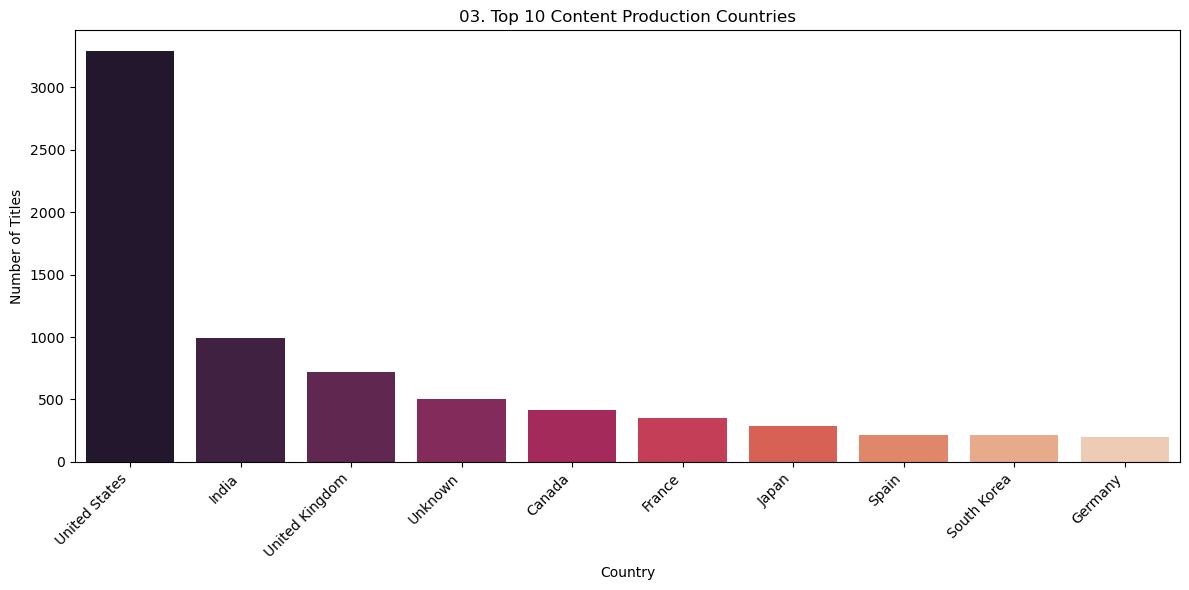

In [ ]:
# What: Identifies the top 10 countries contributing content.
country_data = df[df['Country'] != 'Not Specified']
country_counts = country_data['Country'].str.split(', ', expand=True).stack().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette="rocket")
plt.title('03. Top 10 Content Production Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
# 4. Choropleth Map – Country-wise Content
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
fig = px.choropleth(country_counts, locations="Country", locationmode="country names",
                    color="Count", hover_name="Country",
                    color_continuous_scale="viridis", title="Netflix Content by Country")
fig.show()

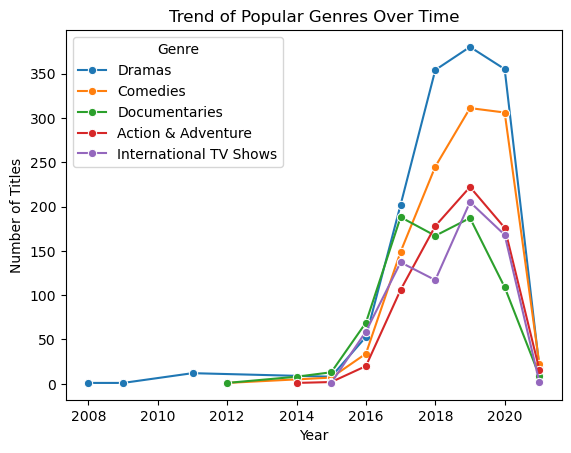

In [ ]:
# 5. Trend Line – Growth of Popular Genres Over Time
popular_genres = df['Main_Genre'].value_counts().head(5).index
genre_trends = df[df['Main_Genre'].isin(popular_genres)].groupby(['Release_Year','Main_Genre']).size().reset_index(name='Count')

sns.lineplot(data=genre_trends, x='Release_Year', y='Count', hue='Main_Genre', marker="o")
plt.title("Trend of Popular Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Genre")
plt.show()

C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\519129907.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




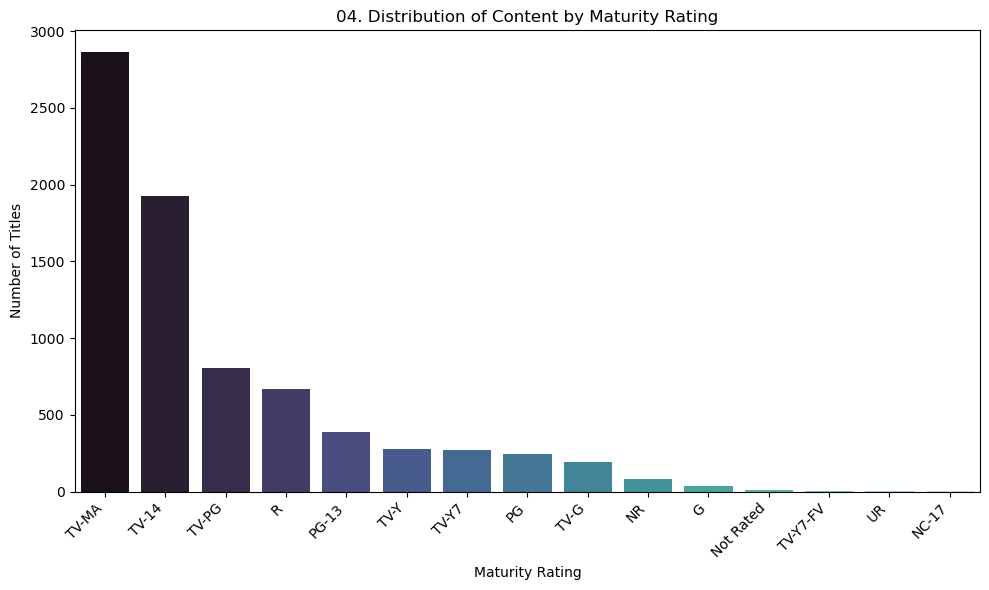

In [ ]:
# --- Visual 4: Rating Distribution (Bar Plot) ---
# What: Shows the content distribution across maturity ratings.
rating_counts = df['Rating'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="mako")
plt.title('04. Distribution of Content by Maturity Rating')
plt.xlabel('Maturity Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description',
       'Release_Year', 'Release_Month', 'Main_Genre'],
      dtype='object')

In [ ]:
# Separate dataframes for convenience
df_movies = df[df['Category'] == 'Movie']
df_tv_shows = df[df['Category'] == 'TV Show']

<>:2: SyntaxWarning:

invalid escape sequence '\d'

<>:2: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\2007395067.py:2: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\2007395067.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



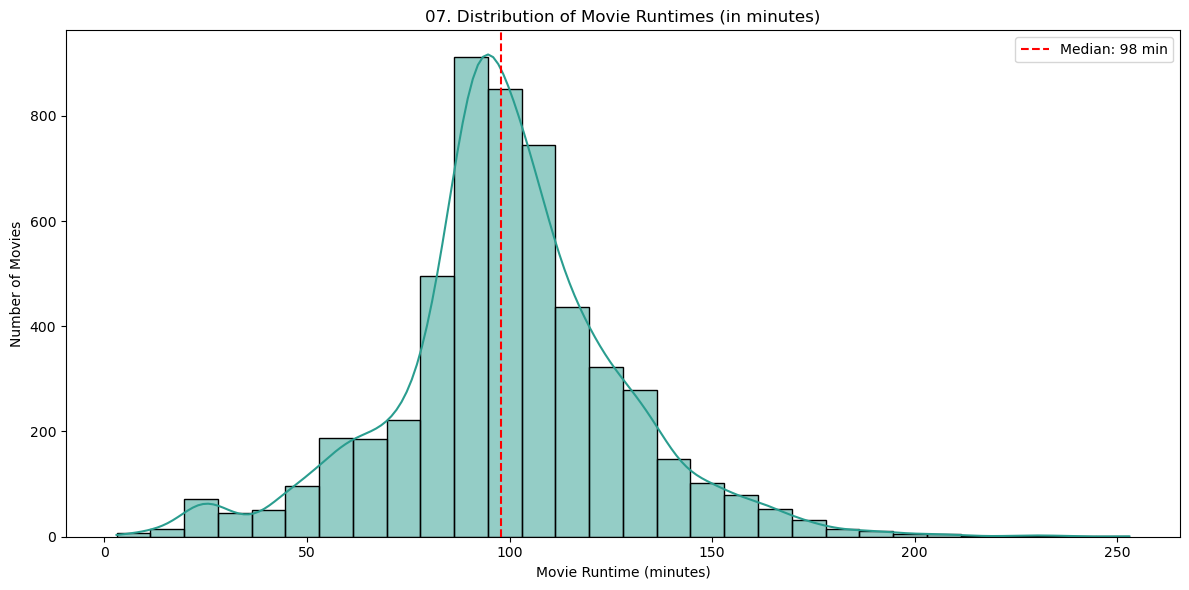

In [ ]:
# Extract numeric duration values from movies
df_movies['Duration_Num'] = df_movies['Duration'].str.extract('(\d+)').astype(float)

# Filter movies with reasonable durations (less than 300 minutes)
df_movie_runtime = df_movies[df_movies['Duration_Num'] < 300]

plt.figure(figsize=(12, 6))
sns.histplot(df_movie_runtime['Duration_Num'], bins=30, kde=True, color='#2a9d8f')
median_runtime = df_movie_runtime['Duration_Num'].median()
plt.axvline(median_runtime, color='red', linestyle='--', label=f'Median: {median_runtime:.0f} min')
plt.title('07. Distribution of Movie Runtimes (in minutes)')
plt.xlabel('Movie Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.tight_layout()

C:\Users\gupta\AppData\Local\Temp\ipykernel_17748\3619767028.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




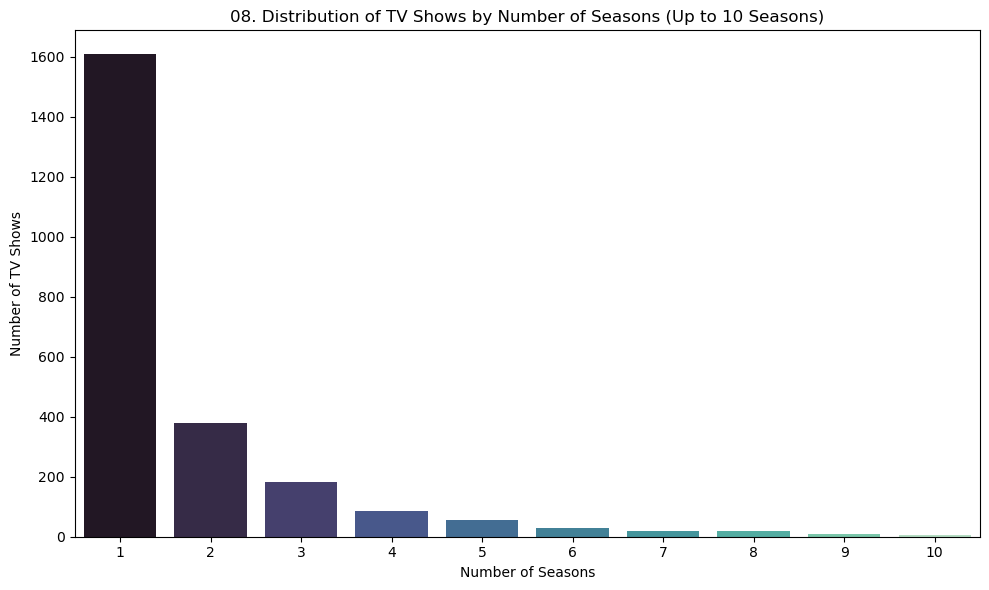

In [242]:
# Select TV shows that have season information in the Duration text
df_tv_seasons = df_tv_shows[df_tv_shows['Duration'].str.contains('season', case=False, na=False)].copy()

# Extract numeric number of seasons
df_tv_seasons['Duration_Num'] = df_tv_seasons['Duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 6))
sns.barplot(x=season_counts_limited.index, y=season_counts_limited.values, palette="mako")
plt.title('08. Distribution of TV Shows by Number of Seasons (Up to 10 Seasons)')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=0)
plt.tight_layout()

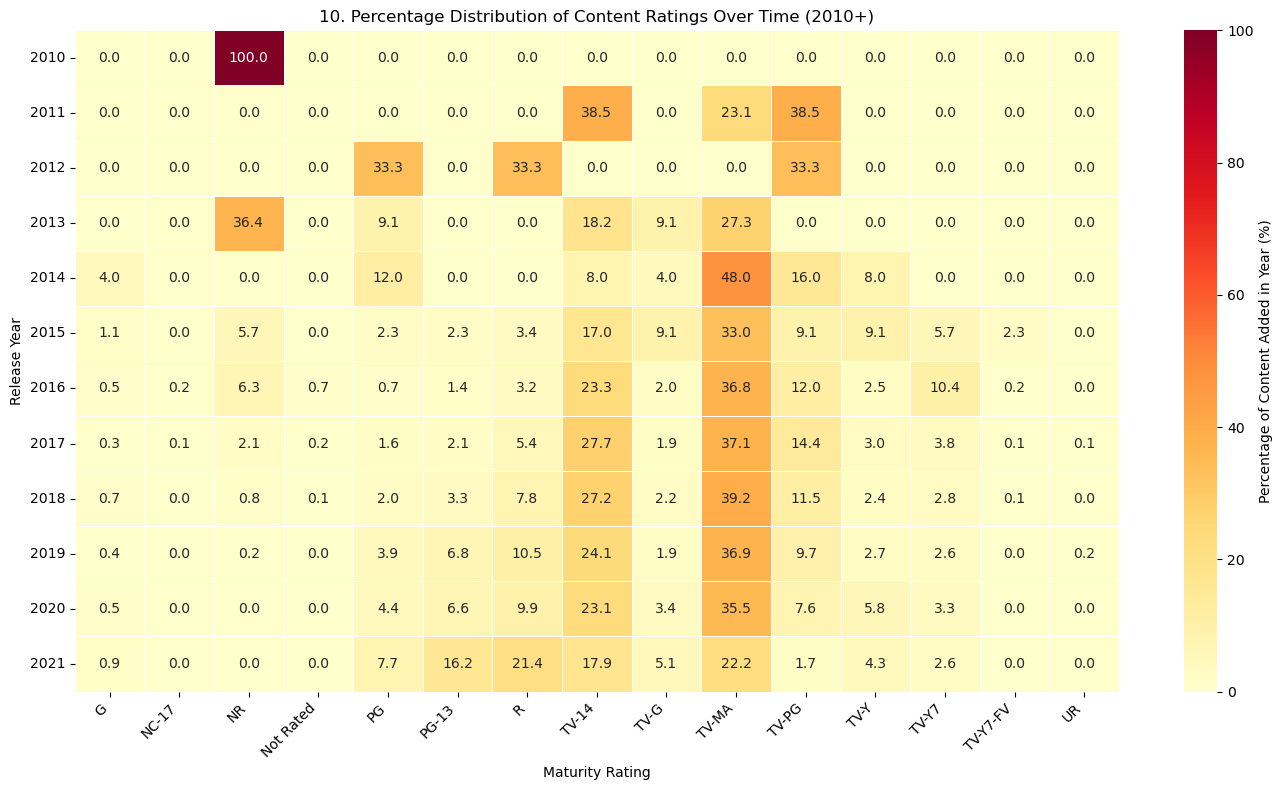

In [245]:
# --- Visual 10: Content Rating Distribution by Release Year (Heatmap) ---
# What: Shows the evolution of target audience focus by tracking the percentage of each rating over time.
df_heatmap = df_recent[df_recent['Rating'] != 'Not Specified']
df_heatmap = df_heatmap[df_heatmap['Release_Year'] >= 2010]

rating_pivot = df_heatmap.pivot_table(
    index='Release_Year',
    columns='Rating',
    values='Show_Id',
    aggfunc='count'
).fillna(0)

rating_pivot_normalized = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(
    rating_pivot_normalized,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Percentage of Content Added in Year (%)'}
)
plt.title('10. Percentage Distribution of Content Ratings Over Time (2010+)')
plt.xlabel('Maturity Rating')
plt.ylabel('Release Year')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [247]:
# Saving the cleaned data fro Dashboarding
df.to_csv("netflix_cleaned_data.csv", index=False)